In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load the dataset
df = pd.read_csv('../data/cs-training.csv', index_col=0)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dataset shape: (150000, 11)
Columns: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [7]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

In [6]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [12]:
print(df['SeriousDlqin2yrs'].value_counts())
print()
print("Proportion of defaults:")
print(df['SeriousDlqin2yrs'].value_counts(normalize=True))

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Proportion of defaults:
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


In [14]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing, 
    'Missing %': missing_pct.round(2)  # round(2) = 2 xonagacha yaxlitlash
})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62


In [24]:
print(f"Min age: {df['age'].min()}")  # .min() ustundagi eng kichik qiymat
print(f"Max age: {df['age'].max()}")  # .max() ustundagi eng katta qiymat
print()
print(f"Count of age = 0: {(df['age'] == 0).sum()}")
print(f"Count of age = 109: {(df['age'] == 109).sum()}")
print(f"Count of age = 99-107: {(df['age'].isin(range(99,108))).sum()}")


Min age: 0
Max age: 109

Count of age = 0: 1
Count of age = 109: 2
Count of age = 99-107: 20


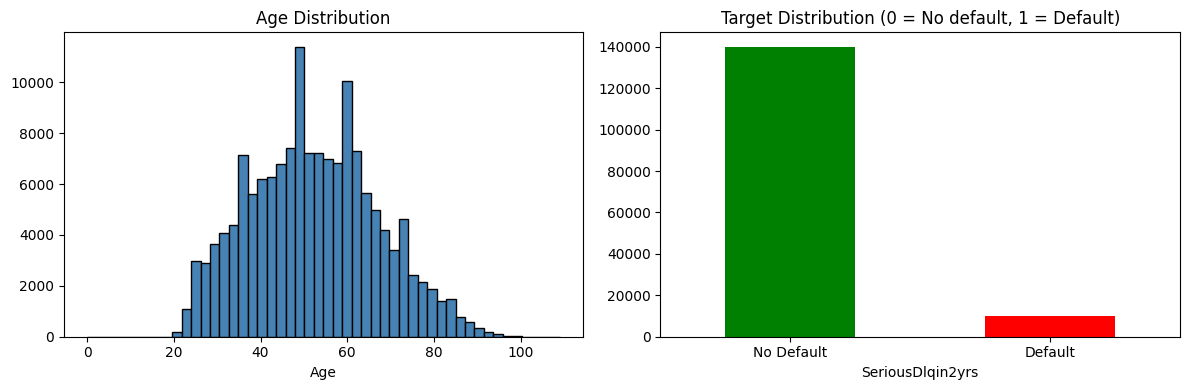

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df['age'], bins=50, color='steelblue', edgecolor='black')
ax[0].set_title('Age Distribution')  # grafik sarlavhasi
ax[0].set_xlabel('Age')  
df['SeriousDlqin2yrs'].value_counts().plot(kind='bar', ax=ax[1], color=['green', 'red'])
ax[1].set_title('Target Distribution (0 = No default, 1 = Default)')
ax[1].set_xticklabels(['No Default', 'Default'], rotation=0)
plt.tight_layout()
plt.show()

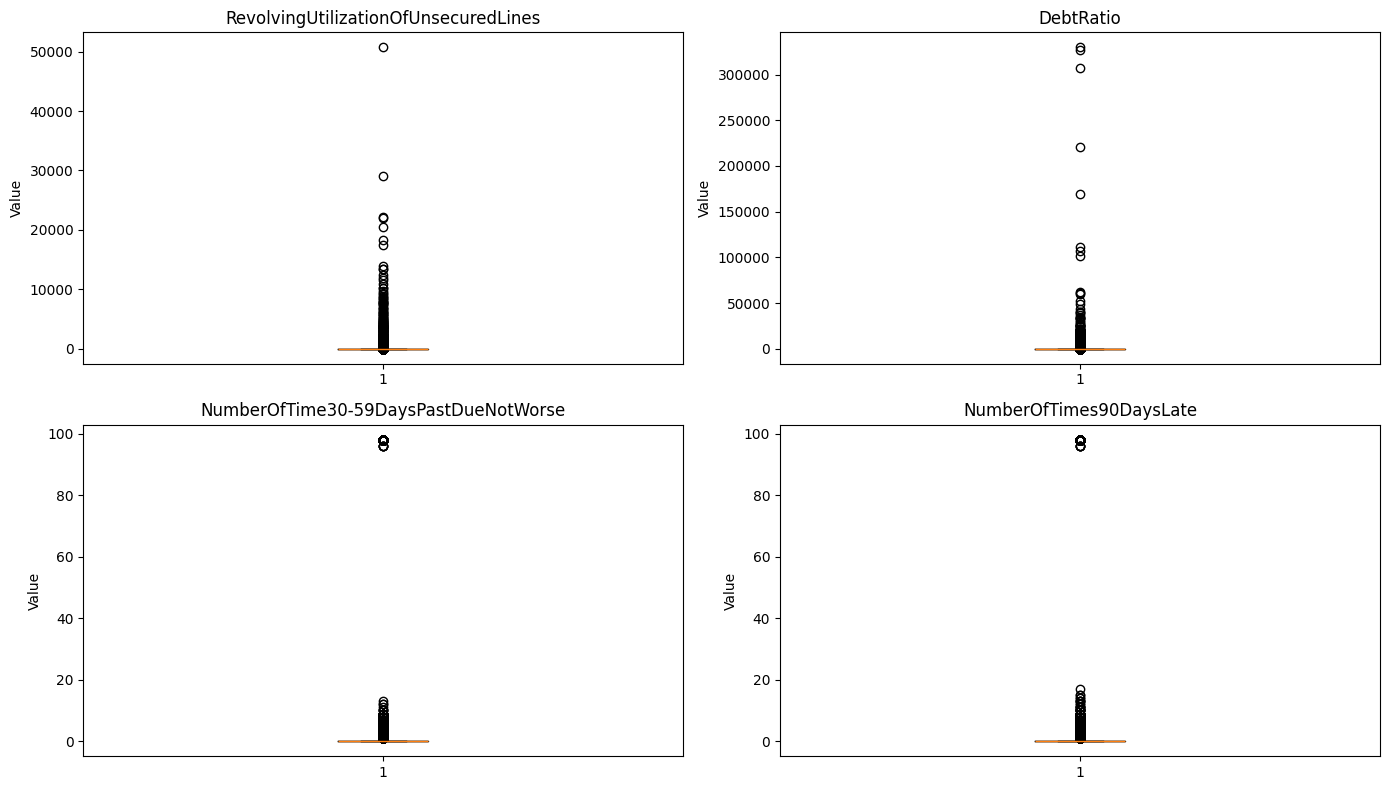

In [29]:
columns_to_check = [
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# axes endi 2D massiv (2x2). Uni 1D ga aylantirib oson aylanish uchun:
# .flatten() — 2D massivni 1D ga aylantiradi: [[a,b],[c,d]] → [a,b,c,d]
axes = axes.flatten()

# enumerate — har bir element bilan birga uning indeksini beradi
# Bu loop har bir ustun uchun bittadan boxplot chizadi
for i, col in enumerate(columns_to_check):
    # i = 0, 1, 2, 3 (indeks)
    # col = ustun nomi
    
    # boxplot chizish — pandas'ning .boxplot() metodi orqali emas,
    # to'g'ridan-to'g'ri matplotlib orqali, ko'proq nazorat uchun
    axes[i].boxplot(df[col].dropna())  # dropna() — bo'sh qiymatlarni o'tkazib yuborish
    axes[i].set_title(f'{col}')         # f-string bilan sarlavha
    axes[i].set_ylabel('Value')         # y o'qi nomi

plt.tight_layout()  # grafiklar bir-biriga tegmasligi uchun
plt.show()


In [42]:
# Null monthly income bo'lgan qatorlardagi DebtRatio statistikasi
null_income_df = df[df['MonthlyIncome'].isnull()]

print(f"Qatorlar soni (null income): {len(null_income_df)}")
print(f"DebtRatio min:    {null_income_df['DebtRatio'].min()}")
print(f"DebtRatio max:    {null_income_df['DebtRatio'].max()}")
print(f"DebtRatio median: {null_income_df['DebtRatio'].median()}")

# Endi taqqoslash uchun normal qatorlar
non_null_df = df[df['MonthlyIncome'].notnull()]
print(f"\nQatorlar soni (normal income): {len(non_null_df)}")
print(f"DebtRatio median: {non_null_df['DebtRatio'].median()}")

Qatorlar soni (null income): 29731
DebtRatio min:    0.0
DebtRatio max:    329664.0
DebtRatio median: 1159.0

Qatorlar soni (normal income): 120269
DebtRatio median: 0.296022604


In [48]:
null_income_df= df[df['MonthlyIncome'].isnull()]
high_debt_in_null=(null_income_df['DebtRatio']>1 ).sum()
total_null =len(null_income_df)
percent= (high_debt_in_null/ total_null)*100
print(f"Null income qatorlardagi DebtRatio >1: {high_debt_in_null}dan {total_null}")
print(f"Foizi: {percent:.2f}%")

non_null_df= df[df['MonthlyIncome'].notnull()]
high_debt_in_null=(non_null_df['DebtRatio']>1 ).sum()
total_null =len(non_null_df)
percent= (high_debt_in_null/ total_null)*100
print(f"Null income qatorlardagi DebtRatio >1: {high_debt_in_null}dan {total_null}")
print(f"Foizi: {percent:.2f}%")

Null income qatorlardagi DebtRatio >1: 27904dan 29731
Foizi: 93.85%
Null income qatorlardagi DebtRatio >1: 7233dan 120269
Foizi: 6.01%


### DebtRatio anomaly — investigation

**Gipoteza**: MonthlyIncome null bo'lganda DebtRatio buziladi.

**Tahlil natijasi**:
| Guruh | DebtRatio median | DebtRatio > 1 foizi |
|-------|------------------|---------------------|
| Income null | 1159.0 | 93.85% |
| Income normal | 0.296 | 6.01% |

**Xulosa**: Gipoteza tasdiqlandi. Income null bo'lgan qatorlarda 
DebtRatio Income bilan nisbat qilinmagan, balki boshqa qiymat  (ehtimol `mutloq qarz` miqdori yozib qo'yilgan).

**Keyingi qadam**: Data cleaning bosqichida income null qatorlarni 
alohida ko'rib chiqish kerak — yoki imputation, yoki yangi feature 
qo'shish (`income_missing_flag`).